In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
from scipy.spatial import distance
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load dims and raw data

## dim `meals`

In [4]:
meals = pl.read_excel("data/processed/phase_4/dim_meals.xlsx")
meals.head()

meal_id,meal_type_1,schoolyear,is_kela,is_new,restaurant,meal_type_2,pcs_mean
i64,str,str,bool,bool,str,str,f64
9017,"""vegan""","""24-25""",true,true,"""che-exa-vik""","""vegan-miscellaneous""",116.3425
7201,"""vegan""","""23-24""",false,false,null,null,106.231119
9032,"""vegan""","""23-24""",false,false,null,null,106.231119
9102,"""vegan""","""23-24""",false,false,null,null,106.231119
7010,"""vegetarian""","""24-25""",false,false,"""che-exa-vik""",null,71.0


## dim `meal_names`

In [6]:
meal_names = pl.read_excel("data/processed/phase_4/dim_meal_names.xlsx")
meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


## dim `opentime`

In [7]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


## dim meal names' embedding

In [8]:
meal_embds = pl.read_parquet("data/inter/meal_names_embds.parquet").drop('__index_level_0__', 'meal')
meal_embds.head()

meal_id,embedding
i64,list[f64]
7010,"[0.011678, -0.039025, … 0.035513]"
7010,"[0.01346, -0.047018, … 0.038673]"
1751,"[0.050395, 0.037269, … 0.025638]"
1751,"[0.065942, 0.037054, … 0.022381]"
200006,"[0.020469, 0.026279, … 0.028041]"


In [9]:
meal_embds = meal_embds.group_by('meal_id').first()
meal_embds.head()

meal_id,embedding
i64,list[f64]
1292,"[0.17264, -0.08472, … 0.01528]"
9500073,"[0.06137, -0.051735, … 0.002372]"
9500042,"[0.046666, 0.106585, … 0.024802]"
7002,"[0.041687, 0.009199, … 0.025802]"
9058,"[0.165976, -0.018319, … 0.019109]"


In [10]:
meal_embds = meal_embds.join(meal_embds, how='cross')

embds_1 = meal_embds.get_column('embedding').to_numpy()
embds_2 = meal_embds.get_column('embedding_right').to_numpy()
dist = [distance.cosine(e1, e2) for e1, e2 in zip(embds_1, embds_2)]

meal_embds = meal_embds.with_columns(pl.Series(dist).alias('dist')).drop('embedding', 'embedding_right')

meal_embds.head()

meal_id,meal_id_right,dist
i64,i64,f64
1292,1292,0.0
1292,9500073,0.728256
1292,9500042,0.674354
1292,7002,0.596826
1292,9058,0.687166


## raw POS

In [11]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()

column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


In [12]:
# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
meal_types = meals.select(
    'meal_id',
    pl.col('meal_type_1').alias('meal_type')
)
pos = pos.join(meal_types, on='meal_id', how='left')



# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,i64,f64,str
"""phy""",2023-05-30,1446,10,0.35,"""chicken"""
"""phy""",2023-06-14,1450,1,0.0,"""vegetarian"""
"""vik""",2023-01-24,9500141,168,0.990476,"""fish"""
"""vik""",2024-09-16,1009,12,0.666667,"""vegetarian"""
"""vik""",2024-09-24,9064,58,0.733333,"""vegan"""


# Approach 1: Apply TargetEncoding to all meals

## Encode

In [13]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)


# Encode meal_id
enc_meal_id = TargetEncoder(target_type='continuous')
enc_meal_id.fit(pos_train.select('meal_id'), pos_train.get_column('pcs'))
pos = pos.with_columns(
    pl.Series('meal_id_enc', values=enc_meal_id.transform(pos.select('meal_id'))).arr.first(),
)



# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos.select('restaurant'))
pos = pos.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos.select('restaurant'))).arr.first().cast(pl.Int32),
)



# Encode meal_type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos.select('meal_type'))
pos = pos.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos.select('meal_type'))).arr.first().cast(pl.Int32),
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Add flag to track records are of old/new meals
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))
pos = pos.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_enc,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""phy""",2023-05-30,1446,10,0.35,"""chicken""",11.195782,2,0,0.974928,-0.222521,-0.201299,0.97953,0.5,-0.866025,false
"""phy""",2023-06-14,1450,1,0.0,"""vegetarian""",8.640432,2,4,0.433884,-0.900969,0.299363,-0.954139,1.2246e-16,-1.0,false
"""vik""",2023-01-24,9500141,168,0.990476,"""fish""",102.65619,3,1,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,false
"""vik""",2024-09-16,1009,12,0.666667,"""vegetarian""",31.682761,3,4,0.781831,0.62349,-0.101168,-0.994869,-1.0,-1.8370e-16,false
"""vik""",2024-09-24,9064,58,0.733333,"""vegan""",55.81966,3,3,0.974928,-0.222521,-0.988468,0.151428,-1.0,-1.8370e-16,true


## Train

In [14]:
cols_X = [
    'meal_type_enc',
    'restaurant_enc',

    'meal_id_enc', 
    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_type_enc',
    'restaurant_enc',
]


pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_enc,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""phy""",2023-05-30,1446,10,0.35,"""chicken""",11.195782,2,0,0.974928,-0.222521,-0.201299,0.97953,0.5,-0.866025,false
"""phy""",2023-06-14,1450,1,0.0,"""vegetarian""",8.640432,2,4,0.433884,-0.900969,0.299363,-0.954139,1.2246e-16,-1.0,false
"""vik""",2023-01-24,9500141,168,0.990476,"""fish""",102.65619,3,1,0.974928,-0.222521,-0.988468,0.151428,0.5,0.866025,false
"""phy""",2024-02-21,3012,10,0.486667,"""vegan""",6.585308,2,3,0.433884,-0.900969,-0.897805,-0.440394,0.866025,0.5,false
"""vik""",2024-02-22,9500129,103,0.971429,"""chicken""",168.485415,3,0,-0.433884,-0.900969,-0.968077,-0.250653,0.866025,0.5,false


In [15]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


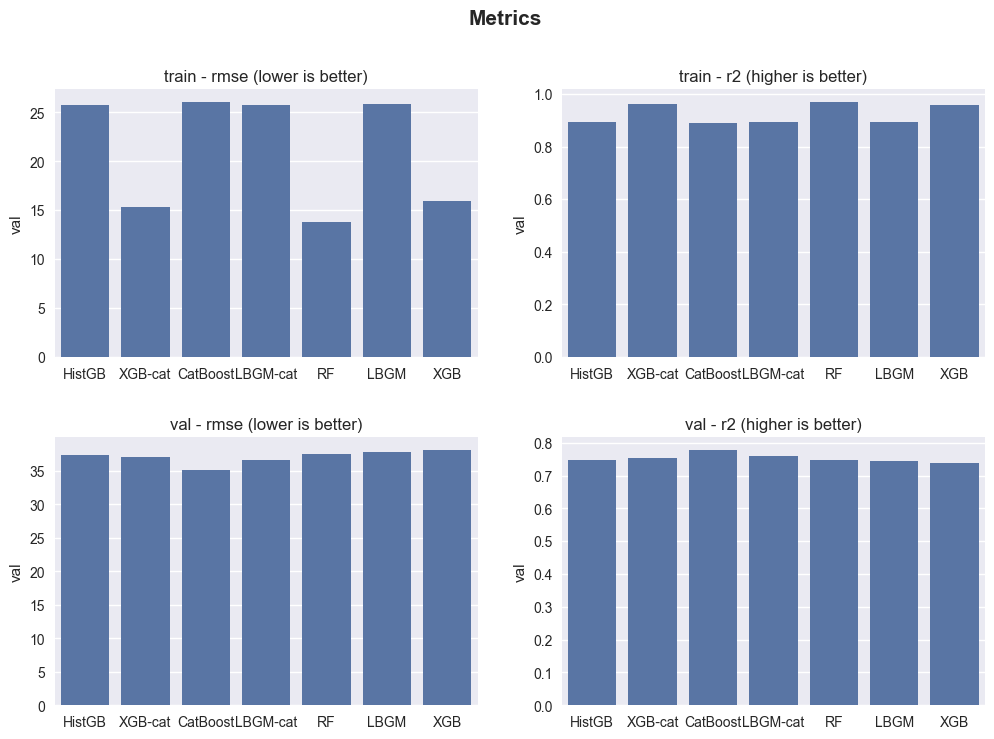

In [16]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split.select(cols_X).to_pandas()
    tgt = split.get_column(col_y).to_pandas()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(tgt, pcs_pred).item()
    r2 = r2_score(tgt, pcs_pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

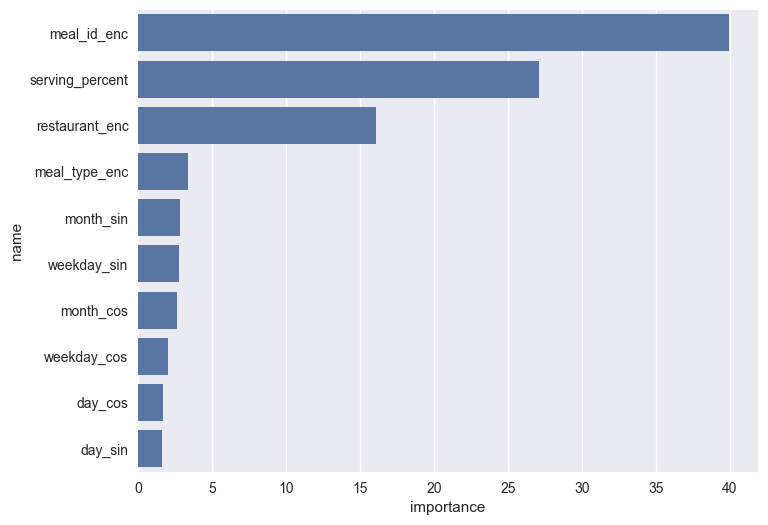

In [17]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [18]:
model = models['CatBoost']

In [19]:
X = pos_val.select(cols_X).to_pandas()
tgt = pos_val.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
pos_val = pos_val.select(
    'restaurant', 'date', 'meal_id', 'pcs', 'serving_percent', 'is_new',
    pl.Series(pcs_pred).alias('pcs_pred')
)

pos_val.head()

restaurant,date,meal_id,pcs,serving_percent,is_new,pcs_pred
str,date,i64,i64,f64,bool,f64
"""vik""",2024-09-16,1009,12,0.666667,false,32.294931
"""vik""",2024-09-24,9064,58,0.733333,true,48.963879
"""exa""",2024-10-08,9500166,2,0.005556,true,4.13543
"""phy""",2024-10-02,6137,20,1.003333,false,21.651472
"""exa""",2024-09-12,9500104,52,0.938889,false,35.478699


In [20]:
split = pos_val.filter(pl.col('is_new'))
r2 = r2_score(split.get_column('pcs'), split.get_column('pcs_pred'))
rmse = root_mean_squared_error(split.get_column('pcs'), split.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 43.7715
r2  : 0.5085


In [21]:
split = pos_val.filter(~pl.col('is_new'))
r2 = r2_score(split.get_column('pcs'), split.get_column('pcs_pred'))
rmse = root_mean_squared_error(split.get_column('pcs'), split.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 34.1976
r2  : 0.7927


# Approach 2: Refer every meals to top K highest sales meals per restaurant and meal_type

In [21]:
CUTOFF_DATE = pl.lit("2024-09-01", dtype=pl.Date)
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)

In [22]:
K = 5
topK = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').sum())
    .with_columns(
        pl.col('pcs').rank(descending=True).over('restaurant', 'meal_type').alias('rank')
    )
    .filter(pl.col('rank') <= K)
    .drop('rank', 'pcs')
)


pcs_mean = (
    pos_train
    .group_by('restaurant', 'meal_type', 'meal_id')
    .agg(pl.col('pcs').mean().alias('pcs_mean'))
)
topK = (
    topK
    .join(pcs_mean, on=['restaurant', 'meal_type', 'meal_id'], how='left')
)

topK.head()

restaurant,meal_type,meal_id,pcs_mean
str,str,i64,f64
"""phy""","""vegan""",6096,14.300493
"""phy""","""vegetarian""",1454,10.702128
"""exa""","""meat""",9500160,69.181818
"""vik""","""vegan""",9500063,91.714286
"""exa""","""vegetarian""",9500118,25.2


In [23]:
meal_embds = meal_embds.join(
    topK.select(pl.col('meal_id').unique()),
    left_on='meal_id_right',
    right_on='meal_id',
    how='inner'
)

meal_embds.head()

meal_id,meal_id_right,dist
i64,i64,f64
1151,6137,0.51519
1151,7025,0.546396
1151,6088,0.795625
1151,9500153,0.241731
1151,9500147,0.53275


In [24]:
pos = (
    pos
    .join(topK, on=['restaurant', 'meal_type'], how='left')
    .join(meal_embds, on=['meal_id', 'meal_id_right'], how='left')
)

pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist
str,date,i64,i64,f64,str,i64,f64,f64
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500098,170.666667,0.617814
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",7599,145.625,0.182774
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500055,142.647059,0.450032
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",880,211.588235,0.618426
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",6156,131.647059,0.310995


## Encode

In [25]:
pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)



# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos.select('restaurant'))
pos = pos.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos.select('restaurant'))).arr.first().cast(pl.Int32),
)


# Encode meal_type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos.select('meal_type'))
pos = pos.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos.select('meal_type'))).arr.first().cast(pl.Int32),
)



# Encode datetime
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Add flag to track records are of old/new meals
meals_old = pos_train.select(pl.col('meal_id').unique()).with_columns(pl.lit(False).alias('is_new'))
pos = pos.join(meals_old, on='meal_id', how='left').with_columns(pl.col('is_new').fill_null(True))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,i64,f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500098,170.666667,0.617814,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",7599,145.625,0.182774,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500055,142.647059,0.450032,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",880,211.588235,0.618426,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",6156,131.647059,0.310995,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false


## Train

In [26]:
cols_X = [
    'meal_id_right',
    'pcs_mean',
    'dist',
    'meal_type_enc',
    'restaurant_enc',
    'serving_percent',
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'meal_id_right',
    'meal_type_enc',
    'restaurant_enc',
]


pos_train = pos.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new
str,date,i64,i64,f64,str,i64,f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500098,170.666667,0.617814,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",7599,145.625,0.182774,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",9500055,142.647059,0.450032,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",880,211.588235,0.618426,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false
"""che""",2023-01-12,9500143,172,0.881481,"""fish""",6156,131.647059,0.310995,0,1,-0.433884,-0.900969,0.651372,-0.758758,0.5,0.866025,false


In [27]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB


Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


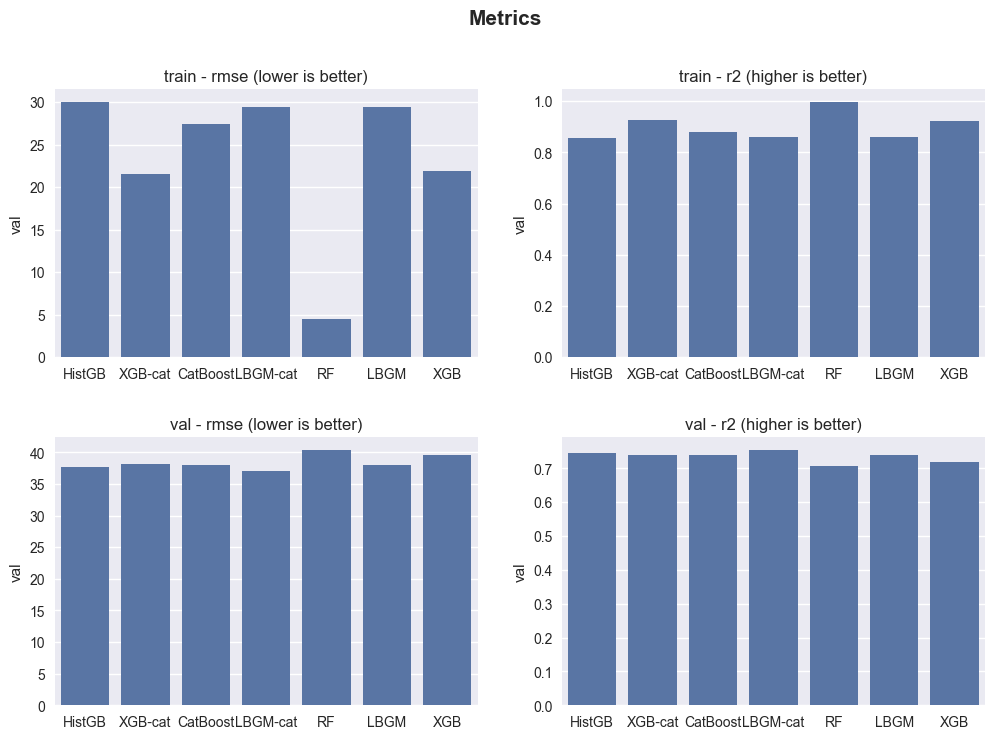

In [28]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    split = split.clone()

    X = split.select(cols_X).to_pandas()
    tgt = split.get_column(col_y).to_pandas()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
    split = (
        split
        .group_by(['date', 'restaurant', 'meal_id', 'meal_type'])
        .agg(
            pl.col('pcs').mean(),
            pl.col('pcs_pred').mean(),
        )
    )
    
    
    rmse = root_mean_squared_error(tgt, pcs_pred).item()
    r2 = r2_score(tgt, pcs_pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

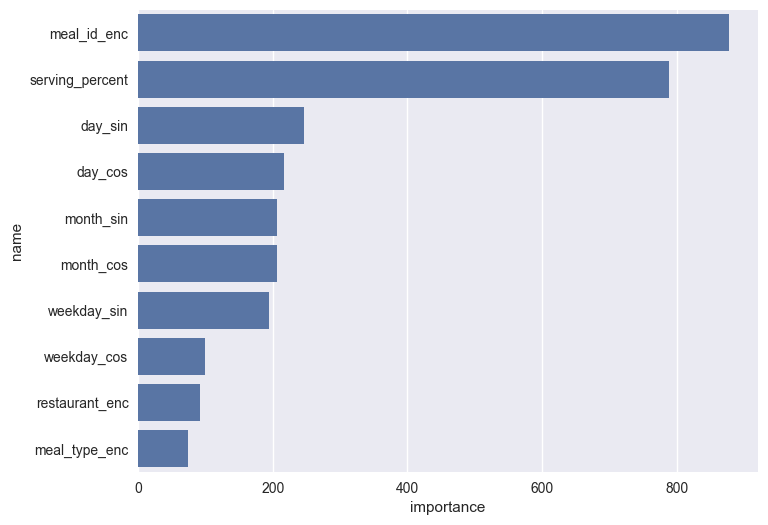

In [22]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['LBGM-cat']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Separately analyze results of old and new meals

In [39]:
model = models['LBGM-cat']

In [40]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))

split.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,meal_id_right,pcs_mean,dist,restaurant_enc,meal_type_enc,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,is_new,pcs_pred
str,date,i64,i64,f64,str,i64,f64,f64,i32,i32,f64,f64,f64,f64,f64,f64,bool,f64
"""phy""",2024-10-28,3012,2,0.256667,"""vegan""",6096,14.300493,0.427595,2,3,0.781831,0.62349,-0.571268,0.820763,-0.866025,0.5,false,5.193947
"""phy""",2024-10-28,3012,2,0.256667,"""vegan""",3524,9.786517,0.584204,2,3,0.781831,0.62349,-0.571268,0.820763,-0.866025,0.5,false,4.998059
"""phy""",2024-10-28,3012,2,0.256667,"""vegan""",3012,6.584112,0.0,2,3,0.781831,0.62349,-0.571268,0.820763,-0.866025,0.5,false,4.800178
"""phy""",2024-10-28,3012,2,0.256667,"""vegan""",6353,7.591463,0.364364,2,3,0.781831,0.62349,-0.571268,0.820763,-0.866025,0.5,false,5.093904
"""phy""",2024-10-28,3012,2,0.256667,"""vegan""",6137,13.943894,0.543047,2,3,0.781831,0.62349,-0.571268,0.820763,-0.866025,0.5,false,4.896314


In [41]:
split = pos_val.clone()

X = split.select(cols_X).to_pandas()
tgt = split.get_column(col_y).to_pandas()

if model['is_cat'] is True:
    for col in cols_cat:
        X[col] = X[col].astype('category')

pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
split = split.with_columns(pl.Series(pcs_pred).alias('pcs_pred'))
    
split = (
    split
    .group_by(['date', 'restaurant', 'meal_id', 'meal_type', 'serving_percent', 'is_new'])
    .agg(
        pl.col('pcs').mean(),
        pl.col('pcs_pred').mean(),
    )
)

split.head()

date,restaurant,meal_id,meal_type,serving_percent,is_new,pcs,pcs_pred
date,str,i64,str,f64,bool,f64,f64
2024-09-10,"""vik""",9068,"""vegan""",0.32381,true,31.0,18.596573
2024-09-25,"""phy""",6137,"""vegan""",0.666667,false,16.0,10.437304
2024-09-04,"""phy""",9500022,"""chicken""",0.643333,false,13.0,10.279773
2024-10-15,"""phy""",1445,"""vegetarian""",1.14,false,36.0,32.05526
2024-09-24,"""phy""",6353,"""vegan""",0.856667,false,3.0,13.90087


In [42]:
split_new = split.filter(pl.col('is_new'))
r2 = r2_score(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_new.get_column('pcs'), split_new.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 42.0545
r2  : 0.5463


In [43]:
split_old = split.filter(~pl.col('is_new'))
r2 = r2_score(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))
rmse = root_mean_squared_error(split_old.get_column('pcs'), split_old.get_column('pcs_pred'))

print(f"rmse: {rmse:.4f}")
print(f"r2  : {r2:.4f}")

rmse: 36.0847
r2  : 0.7692
